(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

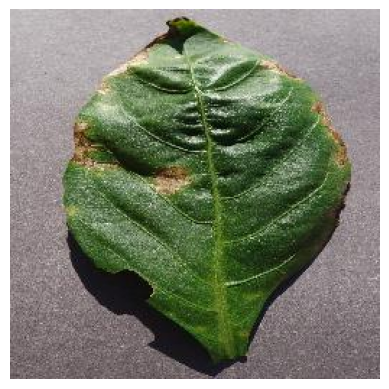

In [1]:
import matplotlib.pyplot as plt
import cv2

# Example image path
img_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/6d15afc9-3066-4ce4-811c-97da31711bf3___NREC_B.Spot 9157.JPG"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [2]:
import os

DATASET_PATH = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

classes = os.listdir(DATASET_PATH)

print("Total Classes:", len(classes))
print(classes)

Total Classes: 15
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [3]:
class_counts = {}

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    class_counts[cls] = len(os.listdir(path))

print(class_counts)

{'Pepper__bell___Bacterial_spot': 997, 'Potato___healthy': 152, 'Tomato_Leaf_Mold': 952, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 3209, 'Tomato_Bacterial_spot': 2127, 'Tomato_Septoria_leaf_spot': 1771, 'Tomato_healthy': 1591, 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676, 'Tomato_Early_blight': 1000, 'Tomato__Target_Spot': 1404, 'Pepper__bell___healthy': 1478, 'Potato___Late_blight': 1000, 'Tomato_Late_blight': 1909, 'Potato___Early_blight': 1000, 'Tomato__Tomato_mosaic_virus': 373}


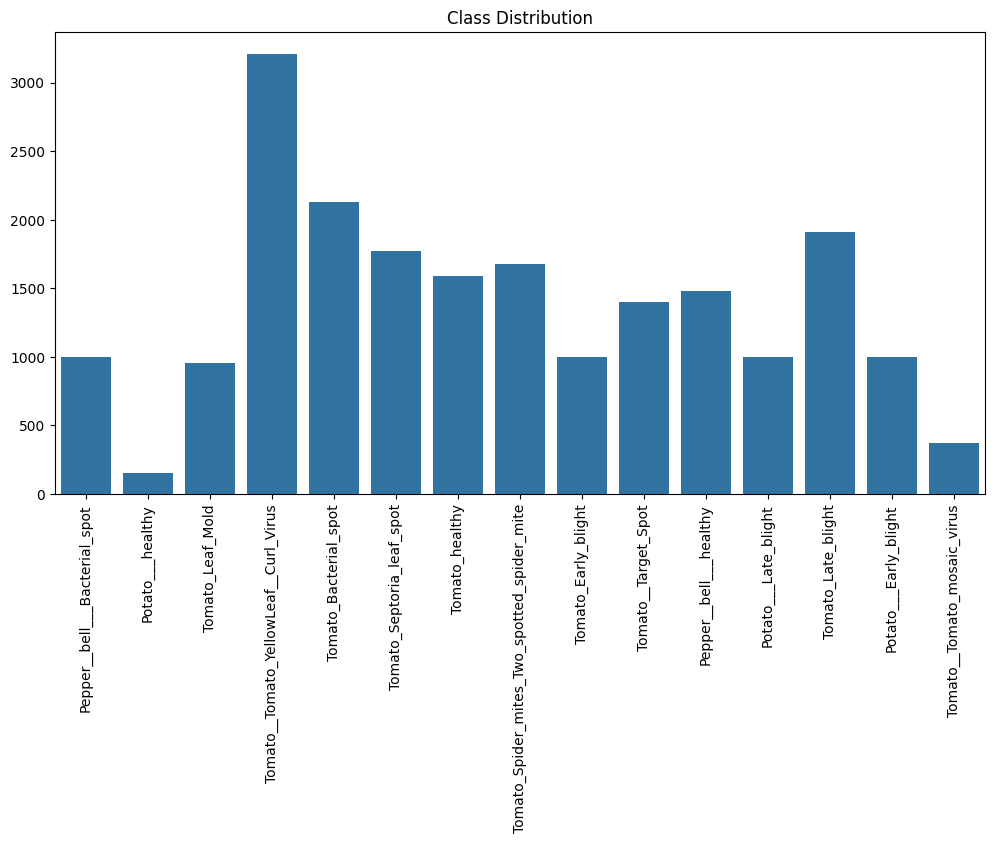

In [4]:
import seaborn as sns
plt.figure(figsize=(12,6))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

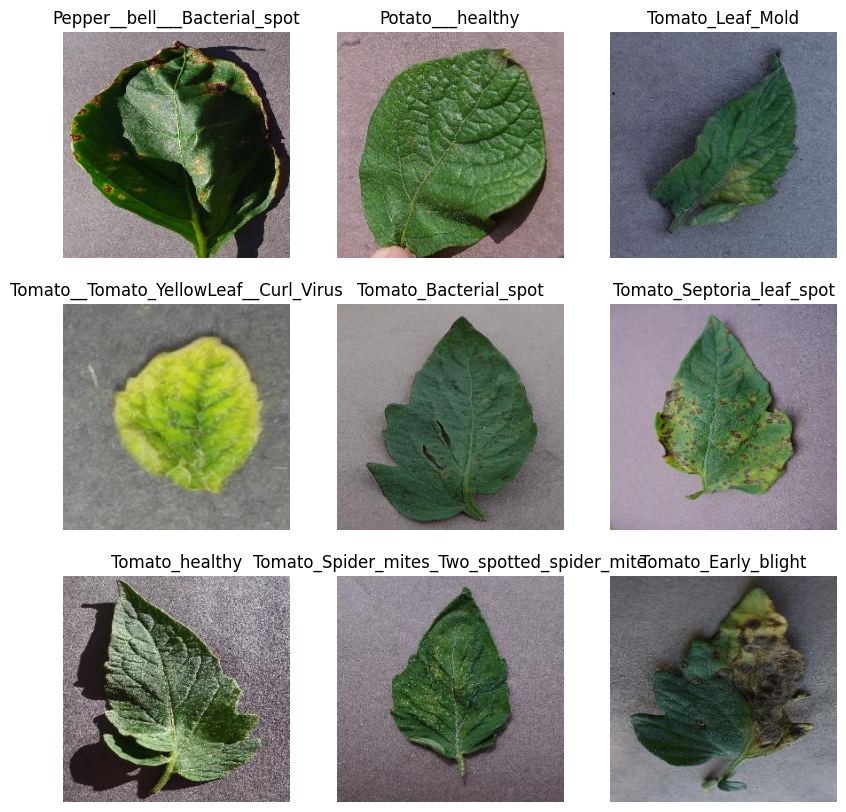

In [5]:
import cv2
plt.figure(figsize=(10,10))

for i, cls in enumerate(classes[:9]):
    
    img_path = os.path.join(DATASET_PATH, cls, os.listdir(os.path.join(DATASET_PATH, cls))[0])
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

2026-03-14 15:57:15.376041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773503835.570692      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773503835.628952      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773503836.116353      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773503836.116396      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773503836.116398      55 computation_placer.cc:177] computation placer alr

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.379782790309106), 1: np.float64(0.9307410538179769), 2: np.float64(1.3763333333333334), 3: np.float64(1.3763333333333334), 4: np.float64(9.025136612021859), 5: np.float64(0.6469251860556209), 6: np.float64(1.3763333333333334), 7: np.float64(0.7205933682373473), 8: np.float64(1.4449693788276465), 9: np.float64(0.7770406963067513), 10: np.float64(0.8210787969177231), 11: np.float64(0.9795966785290628), 12: np.float64(0.4289313076223867), 13: np.float64(3.6824972129319957), 14: np.float64(0.8649384655669023)}


In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

predictions = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

model = Model(inputs=base_model.input, outputs=predictions)

I0000 00:00:1773503954.347643      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773503954.353609      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 374s 706ms/step - accuracy: 0.0651 - loss: 2.7286 - val_accuracy: 0.1589 - val_loss: 2.6450
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 258s 498ms/step - accuracy: 0.1384 - loss: 2.6123 - val_accuracy: 0.1647 - val_loss: 2.5562
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 251s 486ms/step - accuracy: 0.1844 - loss: 2.5570 - val_accuracy: 0.1689 - val_loss: 2.5238
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 248s 480ms/step - accuracy: 0.2136 - loss: 2.4922 - val_accuracy: 0.2926 - val_loss: 2.4092
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 267s 516ms/step - accuracy: 0.2374 - loss: 2.4624 - val_accuracy: 0.2608 - val_loss: 2.3700
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 253s 490ms/step - accuracy: 0.2528 - loss: 2.4301 - val_accuracy: 0.3178 - val_loss: 2.3285
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 247s 478ms/step - accuracy: 0.2762 - loss: 2.3991 - val_accuracy: 0.3086 - val_loss: 2.3096
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 236s 457ms/step - accuracy: 0.3066 -

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Save best model
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights
)

Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.3343 - loss: 2.1853
Epoch 1: val_accuracy improved from -inf to 0.28117, saving model to best_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 267s 499ms/step - accuracy: 0.3343 - loss: 2.1854 - val_accuracy: 0.2812 - val_loss: 2.2423
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.3240 - loss: 2.1710
Epoch 2: val_accuracy improved from 0.28117 to 0.34522, saving model to best_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 242s 467ms/step - accuracy: 0.3240 - loss: 2.1710 - val_accuracy: 0.3452 - val_loss: 2.1422
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.3408 - loss: 2.1725
Epoch 3: val_accuracy improved from 0.34522 to 0.38161, saving model to best_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 246s 476ms/step - accuracy: 0.3408 - loss: 2.1724 - val_accuracy: 0.3816 - val_loss: 2.0666
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.3576 - loss: 2.1277
Epoch 4: val_accuracy

In [12]:
# Unfreeze last 30 layers of base model 
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=80,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights
)

Epoch 1/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.3187 - loss: 6.6927
Epoch 1: val_accuracy improved from 0.46749 to 0.51553, saving model to best_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 264s 475ms/step - accuracy: 0.3189 - loss: 6.6853 - val_accuracy: 0.5155 - val_loss: 1.4674
Epoch 2/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.5475 - loss: 1.3318
Epoch 2: val_accuracy improved from 0.51553 to 0.59874, saving model to best_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 244s 471ms/step - accuracy: 0.5475 - loss: 1.3318 - val_accuracy: 0.5987 - val_loss: 1.1790
Epoch 3/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.5828 - loss: 1.2166
Epoch 3: val_accuracy did not improve from 0.59874
517/517 ━━━━━━━━━━━━━━━━━━━━ 247s 477ms/step - accuracy: 0.5828 - loss: 1.2166 - val_accuracy: 0.5160 - val_loss: 1.4796
Epoch 4/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6058 - loss: 1.1618
Epoch 4: val_accuracy improved from 0.59874 to 0.65648, 

In [13]:
validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
val_loss, val_accuracy = model.evaluate(
    validation_generator,
    verbose=1
)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

Found 4122 images belonging to 15 classes.
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 364ms/step - accuracy: 0.6880 - loss: 0.8809
Validation Accuracy: 0.6955361366271973
Validation Loss: 0.8669787049293518


In [14]:
from sklearn.metrics import classification_report

pred = model.predict(validation_generator)
pred_classes = pred.argmax(axis=1)

print(classification_report(validation_generator.classes, pred_classes))

129/129 ━━━━━━━━━━━━━━━━━━━━ 52s 377ms/step
              precision    recall  f1-score   support

           0       0.61      0.80      0.69       199
           1       0.90      0.74      0.81       295
           2       0.74      0.87      0.80       200
           3       0.73      0.68      0.70       200
           4       0.44      0.77      0.56        30
           5       0.86      0.72      0.78       425
           6       0.39      0.45      0.42       200
           7       0.76      0.49      0.59       381
           8       0.51      0.48      0.50       190
           9       0.60      0.63      0.62       354
          10       0.73      0.63      0.67       335
          11       0.66      0.46      0.54       280
          12       0.73      0.89      0.80       641
          13       0.37      0.88      0.52        74
          14       0.91      0.94      0.93       318

    accuracy                           0.70      4122
   macro avg       0.66      0.69   

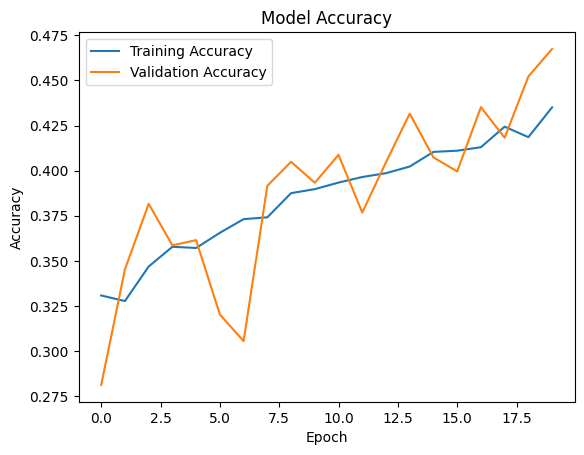

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

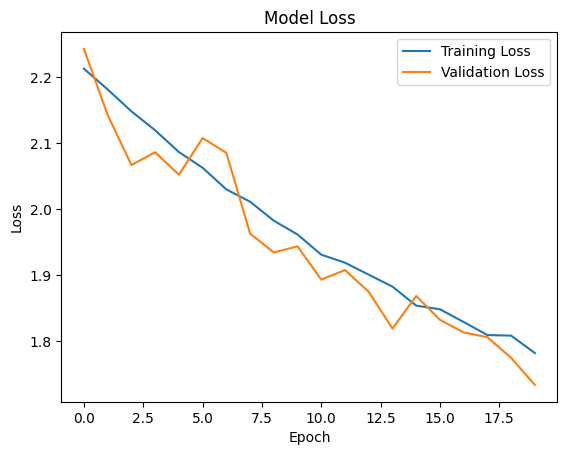

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

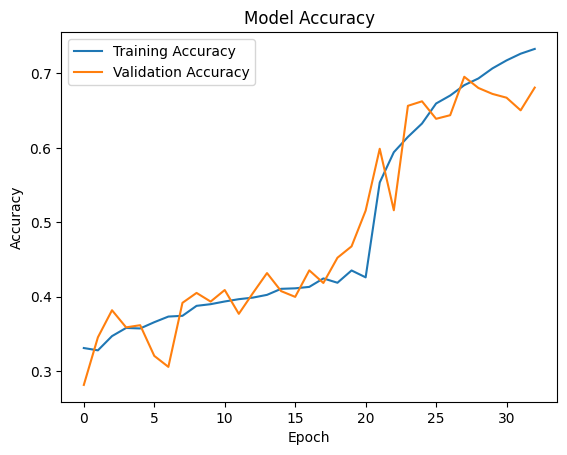

In [17]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

# loss = history_initial.history['loss'] + history_fine.history['loss']
# val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

import matplotlib.pyplot as plt

plt.plot(acc)
plt.plot(val_acc)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

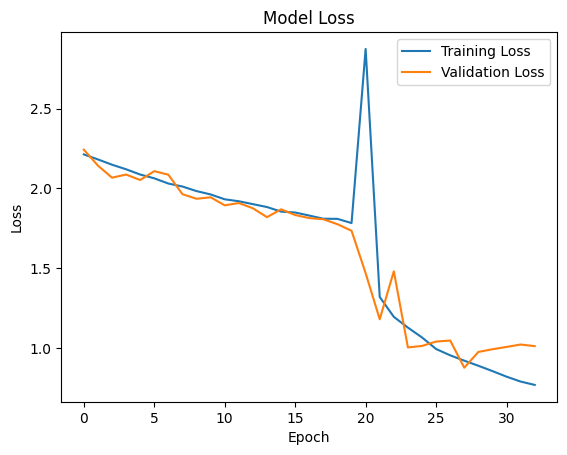

In [18]:
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

import matplotlib.pyplot as plt

plt.plot(loss)
plt.plot(val_loss)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [21]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

# Load saved model
model = load_model("/kaggle/working/best_model.keras")

# Compile model again
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
# Resume training
history_fine_2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=80,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7148 - loss: 0.8377
Epoch 1: val_accuracy improved from 0.69554 to 0.72101, saving model to best_model.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 275s 502ms/step - accuracy: 0.7148 - loss: 0.8377 - val_accuracy: 0.7210 - val_loss: 0.8264
Epoch 2/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7386 - loss: 0.7827
Epoch 2: val_accuracy did not improve from 0.72101
517/517 ━━━━━━━━━━━━━━━━━━━━ 252s 487ms/step - accuracy: 0.7386 - loss: 0.7827 - val_accuracy: 0.6829 - val_loss: 0.9508
Epoch 3/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.7552 - loss: 0.7370
Epoch 3: val_accuracy did not improve from 0.72101
517/517 ━━━━━━━━━━━━━━━━━━━━ 248s 479ms/step - accuracy: 0.7552 - loss: 0.7370 - val_accuracy: 0.7055 - val_loss: 0.8950
Epoch 4/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.7558 - loss: 0.7161
Epoch 4: val_accuracy did not improve from 0.72101
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 471ms/ste

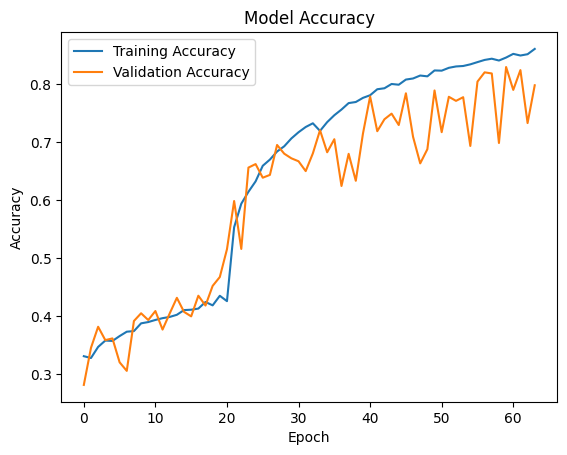

In [22]:
acc = history.history['accuracy'] + history_fine.history['accuracy']+history_fine_2.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']+history_fine_2.history['val_accuracy']

# loss = history_initial.history['loss'] + history_fine.history['loss']
# val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

import matplotlib.pyplot as plt

plt.plot(acc)
plt.plot(val_acc)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

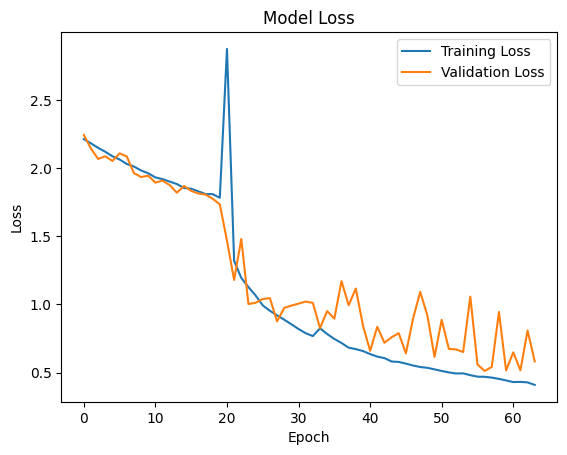

In [23]:
loss = history.history['loss'] + history_fine.history['loss']+history_fine_2.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']+history_fine_2.history['val_loss']

import matplotlib.pyplot as plt

plt.plot(loss)
plt.plot(val_loss)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [24]:
validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
val_loss, val_accuracy = model.evaluate(
    validation_generator,
    verbose=1
)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

Found 4122 images belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


129/129 ━━━━━━━━━━━━━━━━━━━━ 49s 379ms/step - accuracy: 0.8422 - loss: 0.4945
Validation Accuracy: 0.8306647539138794
Validation Loss: 0.5140022039413452


129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 383ms/step


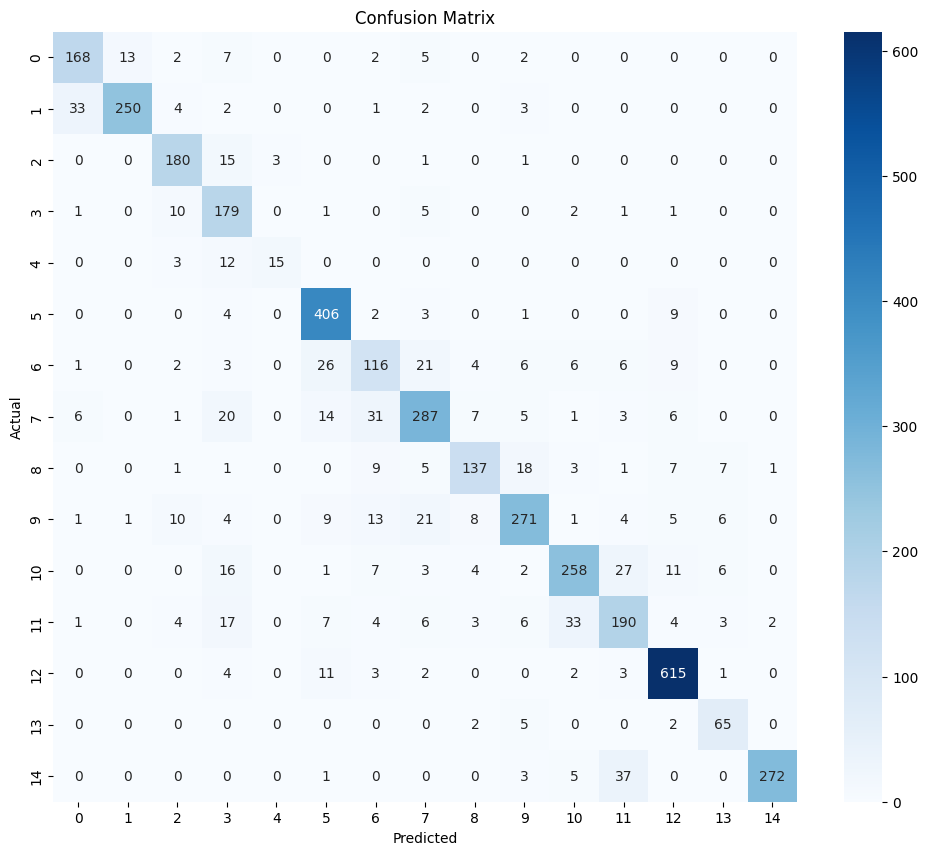

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reset generator
validation_generator.reset()

# Predictions
pred = model.predict(validation_generator)

pred_classes = np.argmax(pred, axis=1)
true_classes = validation_generator.classes

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
from sklearn.metrics import classification_report

class_labels = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.80      0.84      0.82       199
                     Pepper__bell___healthy       0.95      0.85      0.89       295
                      Potato___Early_blight       0.83      0.90      0.86       200
                       Potato___Late_blight       0.63      0.90      0.74       200
                           Potato___healthy       0.83      0.50      0.62        30
                      Tomato_Bacterial_spot       0.85      0.96      0.90       425
                        Tomato_Early_blight       0.62      0.58      0.60       200
                         Tomato_Late_blight       0.80      0.75      0.77       381
                           Tomato_Leaf_Mold       0.83      0.72      0.77       190
                  Tomato_Septoria_leaf_spot       0.84      0.77      0.80       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.83      0.77

In [27]:
# Load saved model
model = load_model("/kaggle/working/best_model.keras")

# Compile model again
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
# Resume training
history_fine_3 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=80,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8471 - loss: 0.4412
Epoch 1: val_accuracy did not improve from 0.83018
517/517 ━━━━━━━━━━━━━━━━━━━━ 278s 508ms/step - accuracy: 0.8471 - loss: 0.4412 - val_accuracy: 0.7686 - val_loss: 0.7339
Epoch 2/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8415 - loss: 0.4465
Epoch 2: val_accuracy did not improve from 0.83018
517/517 ━━━━━━━━━━━━━━━━━━━━ 244s 471ms/step - accuracy: 0.8415 - loss: 0.4465 - val_accuracy: 0.6026 - val_loss: 1.5797
Epoch 3/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8578 - loss: 0.4140
Epoch 3: val_accuracy did not improve from 0.83018
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 470ms/step - accuracy: 0.8578 - loss: 0.4140 - val_accuracy: 0.7693 - val_loss: 0.7146
Epoch 4/80
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8535 - loss: 0.4208
Epoch 4: val_accuracy did not improve from 0.83018
517/517 ━━━━━━━━━━━━━━━━━━━━ 250s 484ms/step - accuracy: 0.8535 - loss: 0.4208 - 

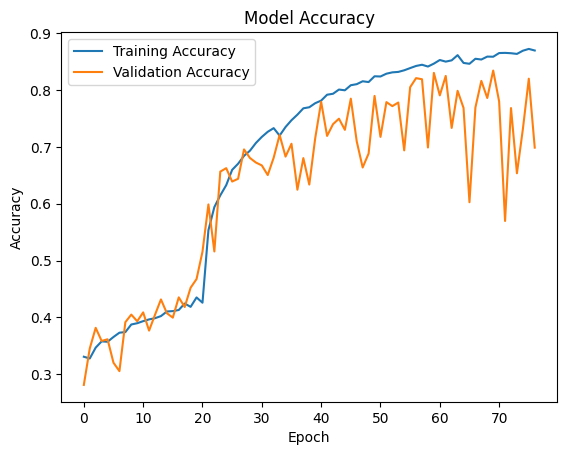

In [28]:
acc = history.history['accuracy'] + history_fine.history['accuracy']+history_fine_2.history['accuracy']+history_fine_3.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']+history_fine_2.history['val_accuracy']+history_fine_3.history['val_accuracy']

# loss = history_initial.history['loss'] + history_fine.history['loss']
# val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

import matplotlib.pyplot as plt

plt.plot(acc)
plt.plot(val_acc)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

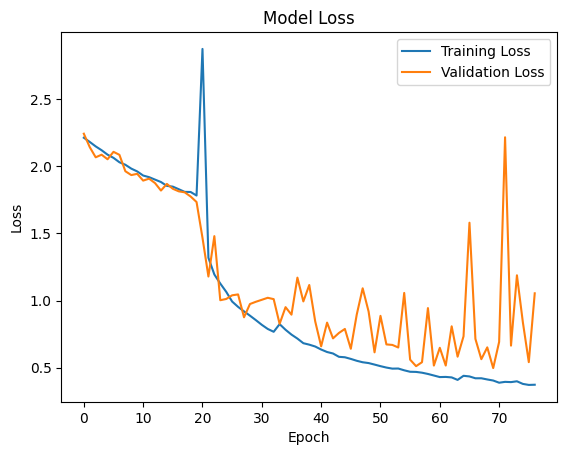

In [29]:
loss = history.history['loss'] + history_fine.history['loss']+history_fine_2.history['loss']+history_fine_3.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']+history_fine_2.history['val_loss']+history_fine_3.history['val_loss']

import matplotlib.pyplot as plt

plt.plot(loss)
plt.plot(val_loss)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 401ms/step


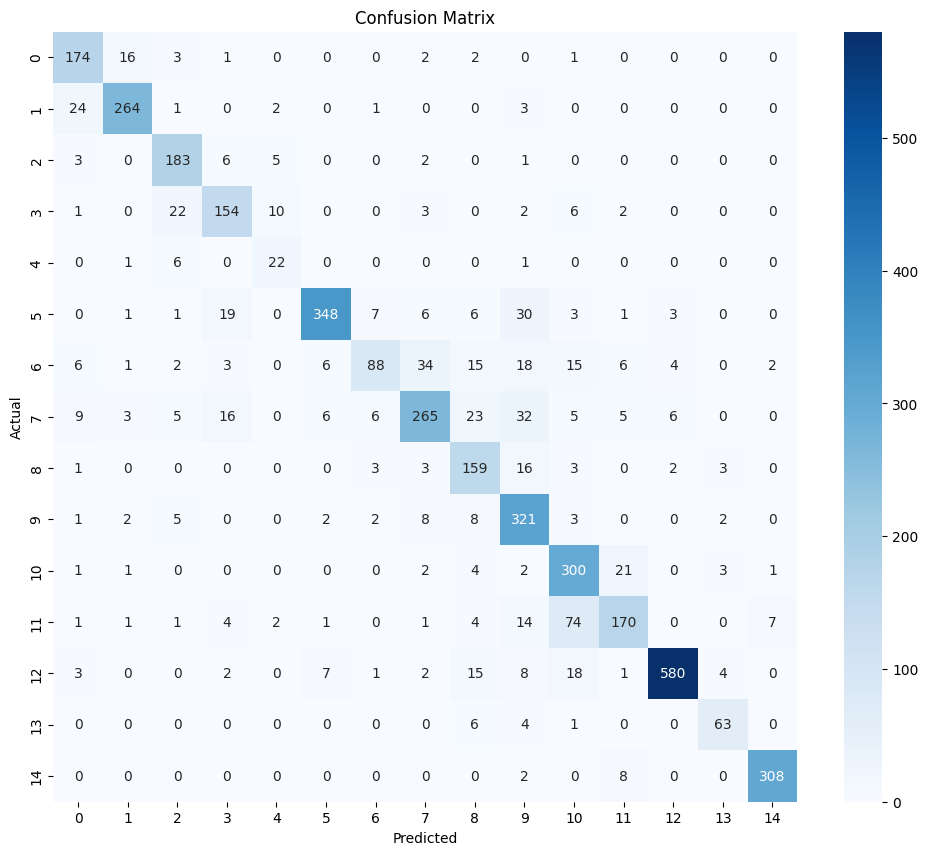

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reset generator
validation_generator.reset()

# Predictions
pred = model.predict(validation_generator)

pred_classes = np.argmax(pred, axis=1)
true_classes = validation_generator.classes

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


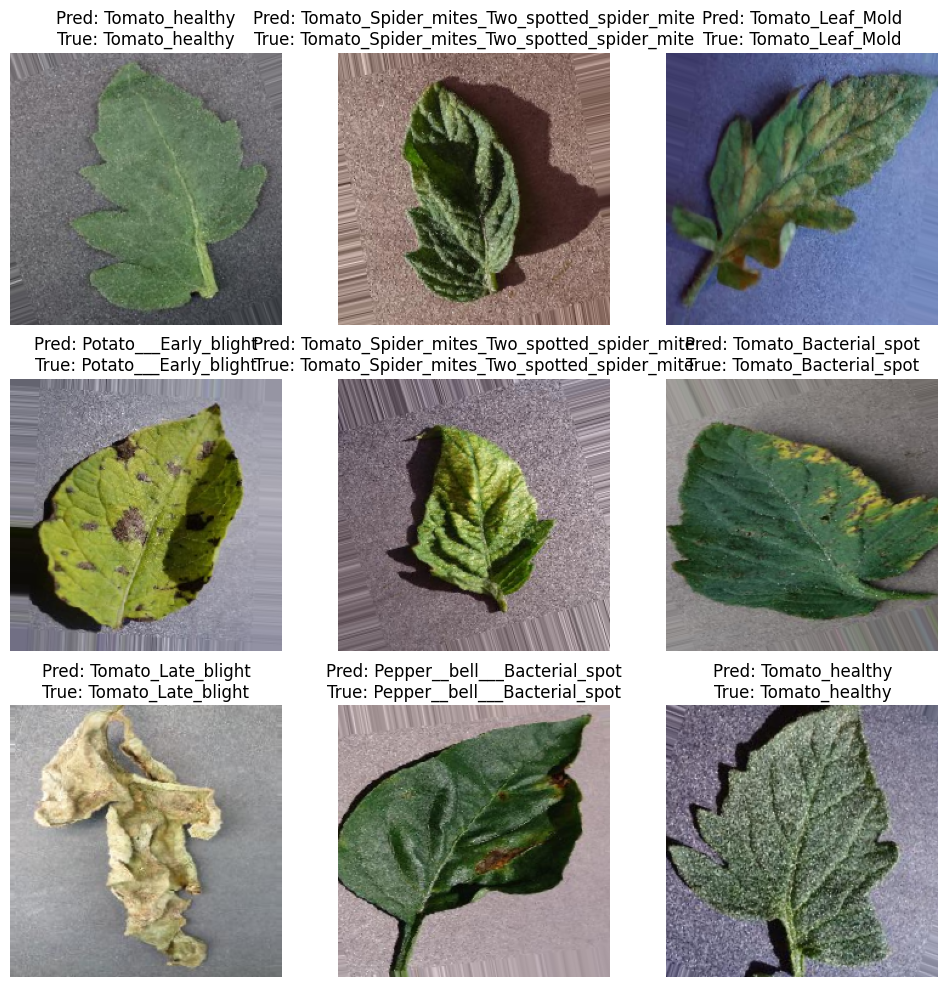

In [17]:
import random
import cv2

class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(12,12))

for i in range(9):
    
    img, label = validation_generator[random.randint(0,len(validation_generator)-1)]
    
    image = img[0]
    true_label = class_names[np.argmax(label[0])]
    
    pred = model.predict(np.expand_dims(image, axis=0))
    pred_label = class_names[np.argmax(pred)]
    
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis("off")

plt.show()

In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


model = load_model("/kaggle/input/datasets/anuroseps/model83/best_model (8).keras")


class_names = list(train_generator.class_indices.keys())

print("Classes:", class_names)


def predict_leaf(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    img_resized = cv2.resize(img, (224,224))

    # Normalize
    img_resized = img_resized / 255.0

    # Expand dimensions
    img_input = np.expand_dims(img_resized, axis=0)

    # Prediction
    prediction = model.predict(img_input)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    # Show image
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    print("Predicted Disease:", predicted_class)
    print("Confidence:", confidence)


predict_leaf("/content/test_leaf.jpg")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/test-leaf/test.jpg'